In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [15]:
X,Y = make_blobs(n_samples=500, centers=3, cluster_std=4, random_state=42)

In [16]:
df = pd.DataFrame(X, columns=['Feature1', 'Feature2'])
df

,Feature1,Feature2
0,-2.282534,-9.692815
1,-6.147668,1.755990
2,13.399091,-1.260023
3,-4.077630,3.160226
4,9.444735,0.340868
...,...,...
495,-1.282205,-3.181575
496,-2.817604,10.378894
497,3.296740,8.649256
498,-8.970519,-2.684073


In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [18]:
WCSS = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    WCSS.append(kmeans.inertia_)

In [19]:
WCSS

[999.9999999999994,
 528.8064432605643,
 294.4377068678185,
 250.4552469653445,
 216.88110656982604,
 185.27440675195913,
 156.70879996290438,
 135.62603453115264,
 129.1039634823981,
 119.94101297104991]

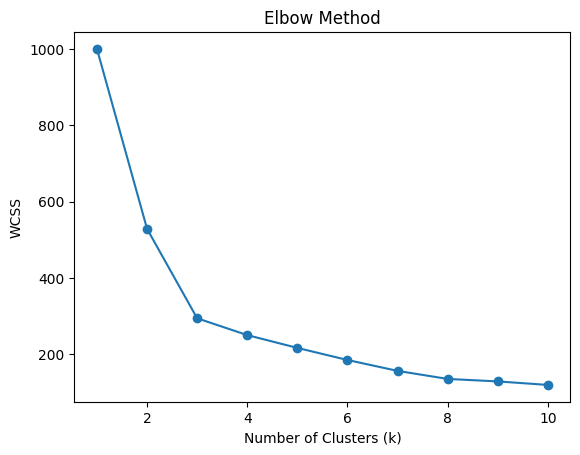

In [20]:
plt.plot(k_range, WCSS, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [21]:
kmeans_final = KMeans(n_clusters=3, random_state=42)

In [22]:
 cluster_labels = kmeans_final.fit_predict(X_scaled)
 cluster_labels

array([1, 2, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 2, 1, 1, 2, 2, 2,
       0, 1, 1, 0, 0, 1, 1, 2, 0, 2, 2, 2, 0, 0, 0, 2, 1, 1, 0, 2, 2, 2,
       0, 0, 0, 0, 0, 1, 1, 2, 1, 1, 0, 2, 2, 1, 0, 1, 1, 2, 0, 1, 0, 1,
       0, 1, 2, 0, 0, 0, 0, 1, 2, 1, 0, 0, 2, 2, 1, 2, 0, 2, 1, 1, 1, 2,
       0, 2, 1, 0, 2, 0, 0, 1, 2, 2, 2, 1, 0, 2, 0, 1, 1, 2, 2, 1, 2, 1,
       1, 1, 2, 1, 1, 2, 2, 1, 0, 1, 2, 2, 0, 0, 0, 0, 2, 0, 1, 1, 1, 0,
       2, 1, 0, 1, 1, 1, 1, 2, 1, 1, 0, 0, 1, 1, 1, 2, 2, 2, 0, 1, 0, 2,
       2, 1, 2, 1, 0, 0, 0, 1, 2, 2, 1, 2, 2, 0, 1, 1, 1, 2, 2, 1, 1, 2,
       2, 2, 0, 0, 2, 1, 0, 2, 1, 1, 0, 0, 2, 1, 1, 1, 1, 1, 2, 0, 2, 2,
       1, 0, 2, 0, 1, 1, 0, 1, 1, 2, 2, 1, 1, 0, 1, 2, 2, 1, 2, 1, 2, 0,
       2, 2, 1, 2, 0, 2, 2, 1, 0, 0, 0, 0, 2, 1, 1, 1, 2, 0, 2, 0, 0, 1,
       2, 2, 1, 1, 0, 2, 2, 0, 2, 0, 2, 2, 0, 2, 1, 2, 0, 2, 2, 2, 1, 2,
       0, 0, 0, 2, 0, 0, 2, 2, 0, 1, 2, 2, 2, 2, 1, 1, 0, 0, 2, 2, 1, 2,
       0, 1, 0, 0, 1, 2, 2, 2, 1, 2, 1, 2, 0, 0, 0,

In [23]:
df['cluster'] = cluster_labels
df

,Feature1,Feature2,cluster
0,-2.282534,-9.692815,1
1,-6.147668,1.755990,2
2,13.399091,-1.260023,0
3,-4.077630,3.160226,2
4,9.444735,0.340868,0
...,...,...,...
495,-1.282205,-3.181575,1
496,-2.817604,10.378894,2
497,3.296740,8.649256,0
498,-8.970519,-2.684073,1


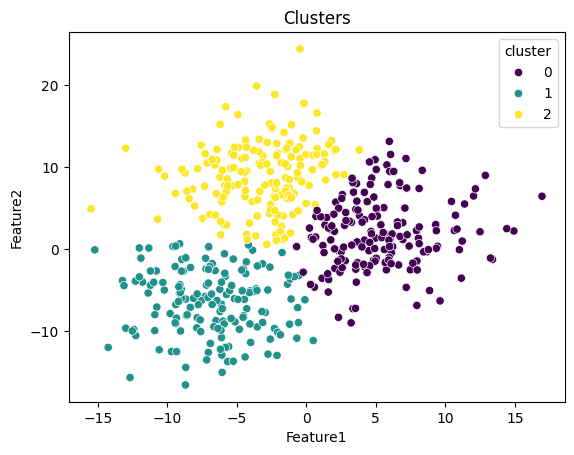

In [24]:
sns.scatterplot(
    x=df['Feature1'],
    y=df['Feature2'],
    hue=df['cluster'],
    palette='viridis'
)

plt.title('Clusters')
plt.show()